In [ ]:
import gdown
id = "1LfAv_C1biyjBNCjq8i5H_aAiKZX6Wy39"
output = "./datalake/"
gdown.download_folder(id=id, output=output)

In [155]:
import pandas as pd
import json
import os
import glob

In [196]:
def load_json_files(file_paths):
    """
    Load data from multiple JSON files
    
    Args:
    file_paths (list): List of file paths to load
    
    Returns:
    list: Combined data from all files
    """
    all_data = []
    for file_path in file_paths:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                # Handle both JSON and JSONL formats
                if file_path.endswith('.json'):
                    data = json.load(f)
                else:  # JSONL
                    data = [json.loads(line) for line in f]
                
                # Ensure data is a list
                if not isinstance(data, list):
                    data = [data]
                
                all_data.extend(data)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
    
    return all_data


In [197]:
def process_books(book_data):
    """
    Process book data
    
    Args:
    book_data (list): List of book dictionaries
    
    Returns:
    tuple: Cleaned books, series set, genre set
    """
    cleaned_books = []
    series_set = set()
    genre_set = set()
    
    for book in book_data:
        # Handle series as a list or string
        series = book.get('series', '')
        if isinstance(series, list):
            series = series[0] if series else ''
        
        # Clean and standardize book data
        cleaned_book = {
            'isbn': book.get('isbn', [''])[0] if isinstance(book.get('isbn'), list) else book.get('isbn', ''),
            'isbn13': book.get('isbn13', [''])[0] if isinstance(book.get('isbn13'), list) else book.get('isbn13', ''),
            'title': book.get('title', ''),
            'image_url': book.get('imageUrl', ''),
            'description': book.get('description', ''),
            'author': book.get('author', ''),
            'num_pages': book.get('numPages', None),
            'language': book.get('language', ''),
            'review_count': book.get('reviewsCount', 0),
            'kindle_price': book.get('ebookPrice', None),
            'publish_date': book.get('publishDate', ''),
            'crawl_source': book.get('crawlSource', ''),
            'average_rating': book.get('averageRating', None),
            'series': series
        }
        
        # Track series
        if cleaned_book['series']:
            series_set.add(cleaned_book['series'])
        
        # Track genres
        genres = book.get('genres', [])
        if isinstance(genres, list):
            genre_set.update(genres)
        elif isinstance(genres, str):
            genre_set.add(genres)
        
        cleaned_books.append(cleaned_book)
    
    return cleaned_books, series_set, genre_set


In [198]:
def process_reviews(review_data):
    """
    Process review data
    
    Args:
    review_data (list): List of review dictionaries
    
    Returns:
    list: Processed reviews
    """
    reviews = []
    
    for review_set in review_data:
        # Handle reviews by book
        if 'rating' in review_set and isinstance(review_set['rating'], list):
            isbn = review_set.get('isbn', [''])[0] if isinstance(review_set.get('isbn'), list) else review_set.get('isbn', '')
            isbn13 = review_set.get('isbn13', [''])[0] if isinstance(review_set.get('isbn13'), list) else review_set.get('isbn13', '')
            
            for rating_entry in review_set['rating']:
                reviews.append({
                    'isbn': isbn,
                    'isbn13': isbn13,
                    'user_id': rating_entry.get('user', None),
                    'rating_score': rating_entry.get('rating', 0)
                })
        
        # Handle reviews by user
        elif 'userId' in review_set and 'rating' in review_set:
            user_id = review_set.get('userId', [''])[0] if isinstance(review_set.get('userId'), list) else review_set.get('userId', '')
            
            for rating_entry in review_set['rating']:
                reviews.append({
                    'isbn': rating_entry.get('isbn', ''),
                    'isbn13': rating_entry.get('isbn13', ''),
                    'user_id': user_id,
                    'rating_score': rating_entry.get('rating', 0)
                })
    
    return reviews



In [199]:
def process_users(user_data):
    """
    Process user data
    
    Args:
    user_data (list): List of user dictionaries
    
    Returns:
    list: Processed users
    """
    processed_users = []
    for user in user_data:
        # Handle variations in user data structure
        user_id = user.get('userId', [''])[0] if isinstance(user.get('userId'), list) else user.get('userId', '')
        name = user.get('name', [''])[0] if isinstance(user.get('name'), list) else user.get('name', '')
        
        processed_user = {
            'user_id': user_id,
            'name': name,
            'profile_url': user.get('profileUrl', [''])[0] if isinstance(user.get('profileUrl'), list) else user.get('profileUrl', ''),
            'total_ratings': user.get('totalRatings', ['0'])[0] if isinstance(user.get('totalRatings'), list) else user.get('totalRatings', '0'),
            'total_reviews': user.get('totalReviews', ['0'])[0] if isinstance(user.get('totalReviews'), list) else user.get('totalReviews', '0'),
            'avg_rating': user.get('avgRating', ['0'])[0] if isinstance(user.get('avgRating'), list) else user.get('avgRating', '0'),
            'image_url': user.get('imageUrl', [''])[0] if isinstance(user.get('imageUrl'), list) else user.get('imageUrl', '')
        }
        
        processed_users.append(processed_user)
    
    return processed_users



In [200]:
def main(base_directory):
    # Define file paths
    books_json_files = [
        os.path.join(base_directory, 'goodreads', 'book_group.json'),
        os.path.join(base_directory, 'goodreads', 'data_50000_60000.json'),
        os.path.join(base_directory, 'goodreads', 'data_60001_70000.json'),
        os.path.join(base_directory, 'goodreads', 'data_70001_80000.json'),
        os.path.join(base_directory, 'goodreads', 'data_80001_90000.json'),
        os.path.join(base_directory, 'goodreads/old', 'book_1_10k.json'),
        os.path.join(base_directory, 'goodreads/old', 'books_200000_to_250000.json'),
        # Add all book JSON file paths here
    ]
    
    reviews_json_files = [
        os.path.join(base_directory, 'goodreads', 'review_50000_60000.json'),
        # os.path.join(base_directory, 'goodreads', 'ratings.json'),
        os.path.join(base_directory, 'goodreads/old', 'reviews.jsonl'),
        os.path.join(base_directory, 'goodreads/old', 'reviews_books_200000_to_250000.json'),
        os.path.join(base_directory, 'goodreads/old', 'data_review1_10k.json'),
        os.path.join(base_directory, 'goodreads/old', 'data_review150-155k.json'),
        os.path.join(base_directory, 'goodreads/old', 'data_review155-160k.json'),
        os.path.join(base_directory, 'goodreads/old', 'data_review160-165k.json'),
        os.path.join(base_directory, 'goodreads/old', 'data_review165-170k.json'),
        os.path.join(base_directory, 'goodreads/old', 'data_review170-175k.json'),
        # Add all review JSON file paths here
    ]
    
    users_json_files = [
        os.path.join(base_directory, 'goodreads', 'group_user.json'),
        os.path.join(base_directory, 'goodreads', 'group1.json'),
        os.path.join(base_directory, 'goodreads/old', 'users.jsonl'),
        os.path.join(base_directory, 'goodreads', 'group_user.json'),
        # Add all user JSON file paths here
    ]
    
    # Load and process data
    print("Loading book data...")
    book_data = load_json_files(books_json_files)
    print(f"Loaded {len(book_data)} book entries")
    
    print("Processing book data...")
    cleaned_books, series_set, genre_set = process_books(book_data)
    
    print("Loading review data...")
    review_data = load_json_files(reviews_json_files)
    print(f"Loaded {len(review_data)} review entries")
    
    print("Processing review data...")
    reviews = process_reviews(review_data)
    
    print("Loading user data...")
    user_data = load_json_files(users_json_files)
    print(f"Loaded {len(user_data)} user entries")
    
    print("Processing user data...")
    users = process_users(user_data)
    
    # Create DataFrames
    books_df = pd.DataFrame(cleaned_books)
    reviews_df = pd.DataFrame(reviews)
    users_df = pd.DataFrame(users)
    
    # Series DataFrame
    series_df = pd.DataFrame({
        'series_id': range(1, len(series_set) + 1),
        'name': list(series_set)
    })
    
    # Genres DataFrame
    genres_df = pd.DataFrame({
        'genre_id': range(1, len(genre_set) + 1),
        'name': list(genre_set)
    })
    
    # Book-Genres DataFrame
    book_genres = []
    for book in book_data:
        if book.get('genres'):
            for genre in book.get('genres', []):
                book_genres.append({
                    'isbn': book.get('isbn', [''])[0] if isinstance(book.get('isbn'), list) else book.get('isbn', ''),
                    'isbn13': book.get('isbn13', [''])[0] if isinstance(book.get('isbn13'), list) else book.get('isbn13', ''),
                    'genre_id': genres_df[genres_df['name'] == genre]['genre_id'].values[0]
                })
    book_genres_df = pd.DataFrame(book_genres)

    
  
    
    # Save to CSV
    books_df.to_csv('clean/books.csv', index=False, mode='w')
    series_df.to_csv('clean/series.csv', index=False, mode='w')
    genres_df.to_csv('clean/genres.csv', index=False, mode='w')
    book_genres_df.to_csv('clean/book_genres.csv', index=False, mode='w')
    reviews_df.to_csv('clean/reviews.csv', index=False, mode='w')
    users_df.to_csv('clean/users.csv', index=False, mode='w')
    
    print("CSV files created successfully!")


In [201]:
main('./datalake/book-rec-datalake')

Loading book data...
Loaded 104300 book entries
Processing book data...
Loading review data...
Loaded 52237 review entries
Processing review data...
Loading user data...
Loaded 36670 user entries
Processing user data...
CSV files created successfully!


In [202]:
# with open('./datalake/book-rec-datalake/goodreads/ratings.json', 'r') as f:
#     data = f.read()
# print(data)

df = pd.read_json('./datalake/book-rec-datalake/goodreads/ratings.json')
df

,userId,rating
0,[145704009],"[{'isbn': '1400341124', 'isbn13': '97814003411..."
1,[8829118],"[{'isbn': '0812998626', 'isbn13': '97808129986..."
2,[63113280],"[{'isbn': '', 'isbn13': '9781984829993', 'book..."
3,[160270339],"[{'isbn': '0312642717', 'isbn13': '97803126427..."
4,[103379996],"[{'isbn': '', 'isbn13': '', 'book_href': 'http..."
...,...,...
1574,[107912421],"[{'isbn': '', 'isbn13': '', 'book_href': 'http..."
1575,[167510184],"[{'isbn': '', 'isbn13': '', 'book_href': 'http..."
1576,[92390881],"[{'isbn': '0525539727', 'isbn13': '97805255397..."
1577,[63665211],"[{'isbn': '0063308312', 'isbn13': '97800633083..."


In [203]:
exploded_df = df.explode('userId').reset_index(drop=True)
exploded_df = exploded_df.explode('rating').reset_index(drop=True)
exploded_df

,userId,rating
0,145704009,"{'isbn': '1400341124', 'isbn13': '978140034112..."
1,145704009,"{'isbn': '1662527004', 'isbn13': '978166252700..."
2,145704009,"{'isbn': '1662529376', 'isbn13': '978166252937..."
3,145704009,"{'isbn': '1662529341', 'isbn13': '978166252934..."
4,145704009,"{'isbn': '166252823X', 'isbn13': '978166252823..."
...,...,...
525779,125982174,"{'isbn': '0439554934', 'isbn13': '978043955493..."
525780,125982174,"{'isbn': '0316015849', 'isbn13': '978031601584..."
525781,125982174,"{'isbn': '0062024035', 'isbn13': '978006202403..."
525782,125982174,"{'isbn': '', 'isbn13': '', 'book_href': 'https..."


In [204]:
expanded_df = pd.concat(
    [exploded_df.drop(columns='rating'), pd.json_normalize(exploded_df['rating'])],
    axis=1
)
expanded_df

,userId,isbn,isbn13,book_href,rating
0,145704009,1400341124,9781400341122,https://www.goodreads.com/book/show/200212922-...,5
1,145704009,1662527004,9781662527005,https://www.goodreads.com/book/show/219754771-...,4
2,145704009,1662529376,9781662529375,https://www.goodreads.com/book/show/220389090-...,4
3,145704009,1662529341,9781662529344,https://www.goodreads.com/book/show/220389457-...,4
4,145704009,166252823X,9781662528231,https://www.goodreads.com/book/show/220389455-...,3
...,...,...,...,...,...
525779,125982174,0439554934,9780439554930,https://www.goodreads.com/book/show/3.Harry_Po...,5
525780,125982174,0316015849,9780316015844,https://www.goodreads.com/book/show/41865.Twil...,5
525781,125982174,0062024035,9780062024039,https://www.goodreads.com/book/show/13335037-d...,5
525782,125982174,,,https://www.goodreads.com/book/show/11870085-t...,5


In [205]:
print(f"Unique ISBN_10: {expanded_df['isbn'].nunique()}, ISBN_13: {expanded_df['isbn13'].nunique()}")
print(f"Unique userId: {expanded_df['userId'].nunique()}")

Unique ISBN_10: 141192, ISBN_13: 143252
Unique userId: 1579


In [206]:
df_to_save = expanded_df.rename(columns={
    "userId": "userid",
    "rating": "rating_score"
})

In [207]:
df_to_save.to_csv(
    'clean/reviews.csv',
    mode='a',
    index=False,
    header=not pd.io.common.file_exists('clean/reviews.csv'),
    columns=["isbn", "isbn13", "userid", "rating_score"]
)

In [168]:
# def clean_csv_files(directory, overwrite=False, suffix="_cleaned"):
#     """
#     Remove rows with NaN values, invalid rating_score values, and duplicates from all CSV files in the directory.

#     Args:
#         directory (str): Path to the directory containing CSV files.
#         overwrite (bool): Whether to overwrite the original files. Defaults to False.
#         suffix (str): Suffix for the cleaned files if not overwriting. Defaults to "_cleaned".
#     """
#     for file_name in os.listdir(directory):
#         if file_name.endswith(".csv"):
#             file_path = os.path.join(directory, file_name)
            
#             try:
#                 # read the csv file with low_memory=False to handle mixed types
#                 df = pd.read_csv(file_path, low_memory=False)
                
#                 # drop rows with NaN values
#                 cleaned_df = df.dropna()
                
#                 # remove rows with invalid rating_score (non-numeric or out of range)
#                 if "rating_score" in cleaned_df.columns:
#                     # Attempt to convert rating_score to numeric; invalid entries will become NaN
#                     cleaned_df.loc[:, "rating_score"] = pd.to_numeric(cleaned_df["rating_score"], errors="coerce")
                    
#                     # keep only valid rating scores (0–5 inclusive)
#                     cleaned_df = cleaned_df[
#                         (cleaned_df["rating_score"].notna()) & 
#                         (cleaned_df["rating_score"].between(0, 5))
#                     ]
#                     cleaned_df["rating_score"] = cleaned_df["rating_score"].astype(float)

#                 # check and remove duplicate rows
#                 duplicates = cleaned_df.duplicated(keep='first')
#                 if duplicates.any():
#                     print(f"Found {duplicates.sum()} duplicate rows in file {file_name}. Removing duplicates.")
#                     cleaned_df = cleaned_df.drop_duplicates()

#                 # define the output file path
#                 if overwrite:
#                     output_file_path = file_path
#                 else:
#                     output_file_path = os.path.join(
#                         directory, file_name.replace(".csv", f"{suffix}.csv")
#                     )
                
#                 # save the cleaned data to a new file
#                 cleaned_df.to_csv(output_file_path, index=False)
#                 print(f"Cleaned file saved to: {output_file_path}")
            
#             except Exception as e:
#                 print(f"Error processing file {file_name}: {e}")


In [208]:
ratings_df = pd.read_csv('./clean/reviews.csv', low_memory=False)
null_count = ratings_df['rating_score'].isnull().sum()
non_numeric = pd.to_numeric(ratings_df['rating_score'], errors='coerce')
non_numeric_count = non_numeric.isnull().sum()
non_null_ratings = ratings_df.loc[ratings_df['rating_score'].notnull(), 'rating_score']
truly_non_numeric_count = pd.to_numeric(non_null_ratings, errors='coerce').isnull().sum()
print(f"Total invalid rows: {null_count + truly_non_numeric_count}")

Total invalid rows: 95590


In [213]:
def clean_csv_files(directory, overwrite=False, suffix="_cleaned"):
    """
    Remove rows with missing critical identifiers or exact duplicates from CSV files in the directory.
    
    Args:
        directory (str): Path to the directory containing CSV files.
        overwrite (bool): Whether to overwrite the original files. Defaults to False.
        suffix (str): Suffix for the cleaned files if not overwriting. Defaults to "_cleaned".
    """
    for file_name in os.listdir(directory):
        if file_name.endswith(".csv"):
            file_path = os.path.join(directory, file_name)
            
            try:
                # read the csv file with low_memory=False to handle mixed types
                df = pd.read_csv(file_path, low_memory=False)
                
                original_rows = len(df)
                print(f"\nProcessing {file_name}")
                print(f"Original number of rows: {original_rows}")
                
                # cleaning strategy
                cleaned_df = df.copy()
                
                # check for isbnor isbn13 columns
                isbn_columns = ['isbn', 'isbn13']
                existing_isbn_columns = [col for col in isbn_columns if col in df.columns]
                
                if existing_isbn_columns:
                    # drop rows where isbn, isbn13 columns are missing or empty
                    cleaned_df = cleaned_df[
                        cleaned_df[existing_isbn_columns].notna().any(axis=1) & 
                        (cleaned_df[existing_isbn_columns] != '').any(axis=1)
                    ]
                    
                # rating_score column
                if 'rating_score' in df.columns:
                    cleaned_df = cleaned_df[cleaned_df['rating_score'].notnull()]
                    cleaned_df.loc[:, "rating_score"] = pd.to_numeric(cleaned_df["rating_score"], errors="coerce")
                    cleaned_df = cleaned_df.dropna(subset=['rating_score'])
                    
                    cleaned_df["rating_score"] = cleaned_df["rating_score"].astype(float)
                
                # remove exact duplicates
                duplicates = cleaned_df.duplicated(keep='first')
                duplicate_count = duplicates.sum()
                
                print(f"Duplicate rows found: {duplicate_count}")
                cleaned_df = cleaned_df.drop_duplicates()
                
                # logging final dataset size
                final_rows = len(cleaned_df)
                print(f"Final number of rows: {final_rows}")
                print(f"Rows removed: {original_rows - final_rows} ({((original_rows - final_rows)/original_rows)*100:.2f}%)")
                
                # save cleaned data
                output_file_path = file_path if overwrite else os.path.join(
                    directory, file_name.replace(".csv", f"{suffix}.csv")
                )
                
                cleaned_df.to_csv(output_file_path, index=False)
                print(f"Cleaned file saved to: {output_file_path}")
            
            except Exception as e:
                print(f"Error processing file {file_name}: {e}")

In [214]:
clean_csv_files(directory="./clean", overwrite=True)


Processing reviews.csv
Original number of rows: 845857
Duplicate rows found: 0
Final number of rows: 845857
Rows removed: 0 (0.00%)
Cleaned file saved to: ./clean/reviews.csv

Processing book_genres.csv
Original number of rows: 327542
Duplicate rows found: 8785
Final number of rows: 317790
Rows removed: 9752 (2.98%)
Cleaned file saved to: ./clean/book_genres.csv

Processing users.csv
Original number of rows: 36670
Duplicate rows found: 13078
Final number of rows: 23592
Rows removed: 13078 (35.66%)
Cleaned file saved to: ./clean/users.csv

Processing genres.csv
Original number of rows: 1022
Duplicate rows found: 0
Final number of rows: 1022
Rows removed: 0 (0.00%)
Cleaned file saved to: ./clean/genres.csv

Processing books.csv
Original number of rows: 104300
Duplicate rows found: 1023
Final number of rows: 102561
Rows removed: 1739 (1.67%)
Cleaned file saved to: ./clean/books.csv

Processing series.csv
Original number of rows: 5949
Duplicate rows found: 0
Final number of rows: 5949
Row

In [215]:
import matplotlib.pyplot as plt
import seaborn as sns

books_df = pd.read_csv('./clean/books.csv')
reviews_df = pd.read_csv('./clean/reviews.csv')
series_df = pd.read_csv('./clean/series.csv')
book_genres_df = pd.read_csv('./clean/book_genres.csv')
genres_df = pd.read_csv('./clean/genres.csv')

num_books = books_df.shape[0]
num_reviews = reviews_df.shape[0]
unique_users = reviews_df['user_id'].nunique() if 'user_id' in reviews_df.columns else None

reviews_per_user = num_reviews / unique_users if unique_users else None
reviews_per_book = num_reviews / num_books

# Print statistics
print(f"Number of books: {num_books}")
print(f"Number of reviews: {num_reviews}")
print(f"Number of unique users: {unique_users}")
print(f"Average reviews per user: {reviews_per_user:.2f}" if reviews_per_user else "User data not available")
print(f"Average reviews per book: {reviews_per_book:.2f}")


/var/folders/4x/ly3sydnx0qj93g5bx9zm4hr80000gn/T/ipykernel_61555/2987648802.py:4: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  books_df = pd.read_csv('./clean/books.csv')


Number of books: 102561
Number of reviews: 845857
Number of unique users: 253687
Average reviews per user: 3.33
Average reviews per book: 8.25


/var/folders/4x/ly3sydnx0qj93g5bx9zm4hr80000gn/T/ipykernel_61555/2987648802.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews_df = pd.read_csv('./clean/reviews.csv')


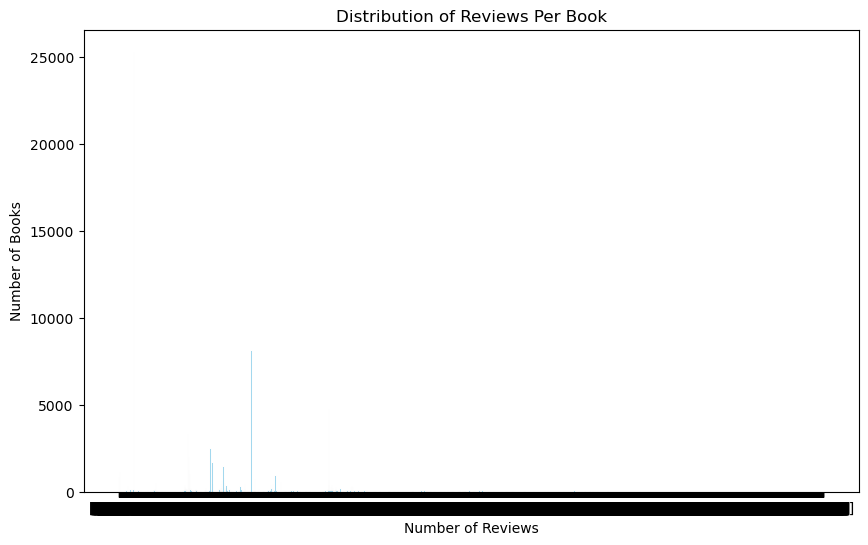

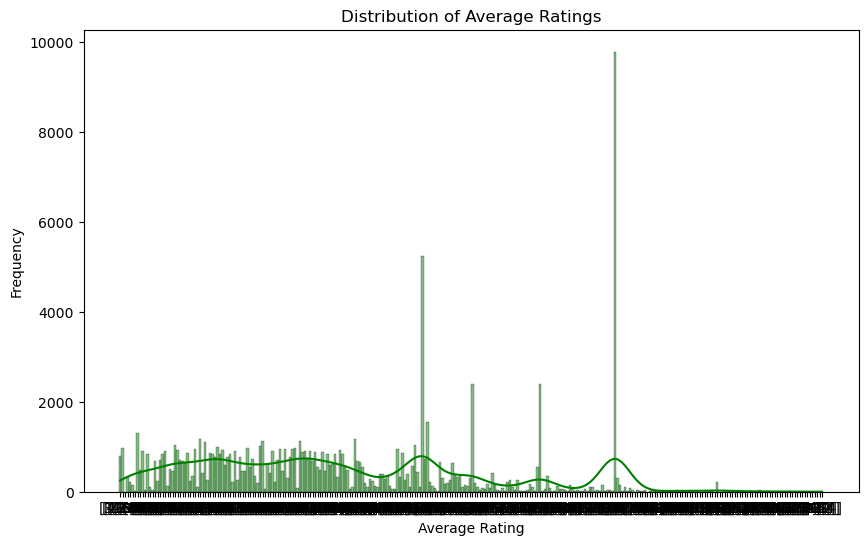

/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 28459 (\N{CJK UNIFIED IDEOGRAPH-6F2B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


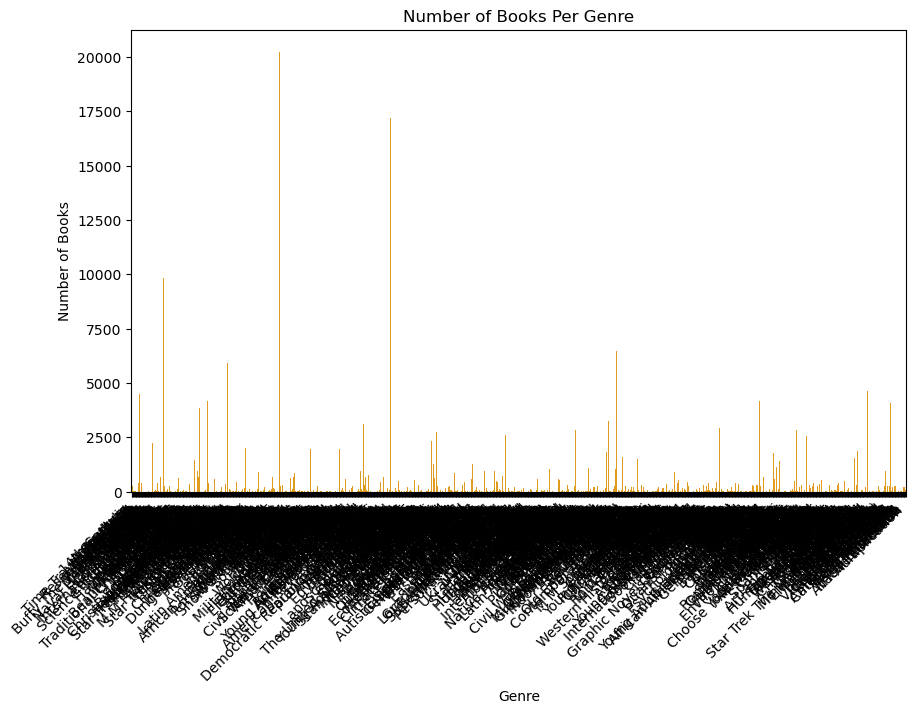

In [216]:
# Visualization: Reviews per book distribution
plt.figure(figsize=(10, 6))
sns.histplot(books_df['review_count'], kde=False, bins=50, color='skyblue')
plt.title("Distribution of Reviews Per Book")
plt.xlabel("Number of Reviews")
plt.ylabel("Number of Books")
plt.show()

# Visualization: Average rating distribution
plt.figure(figsize=(10, 6))
sns.histplot(books_df['average_rating'], kde=True, bins=50, color='green')
plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()

# Series analysis
if 'series_id' in books_df.columns:
    series_counts = books_df['series_id'].value_counts()
    series_df['book_count'] = series_df['series_id'].map(series_counts)
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=series_df['series_id'],
        y=series_df['book_count'],
        color='purple',
    )
    plt.title("Books Per Series")
    plt.xlabel("Series ID")
    plt.ylabel("Number of Books")
    plt.show()

# Genre analysis
book_genres_count = book_genres_df['genre_id'].value_counts()
genres_df['book_count'] = genres_df['genre_id'].map(book_genres_count)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=genres_df['name'],
    y=genres_df['book_count'],
    color='orange',
)
plt.xticks(rotation=45, ha='right')
plt.title("Number of Books Per Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.show()
